<a href="https://colab.research.google.com/github/Mukundan-T/seqADAGE/blob/master/Py/muk_transfer_learning/filtering/Mukundan_ec_filt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E. coli - Filtering

### By: Mukundan Thanigaivelan

#### July 9, 2026

In this notebook, we filter E. coli genes and samples to roughly obtain a normal distribution of our gene expression for inputting into the Denoising AutoEncoder (DAE).

We work with genes in MG1655, and the data have already been filtered based on sparsity and housekeeping genes, as well as log-transformed and 0-1 scaled.

## 1. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

fatal: destination path 'seqADAGE' already exists and is not an empty directory.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning/filtering

/content/seqADAGE/Py/muk_transfer_learning/filtering


In [3]:
!pip install -qq seaborn pydeseq2

## 2. Loading classes & modules

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
import time
import re
import tensorflow as tf
from pydeseq2.preprocessing import deseq2_norm

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 3. Data filtering

Here we are looking at genes in MG1655. Samples have been filtered
by sparsity and housekeeping gene expression.

The data has been log transformed and scaled to be between 0 and 1.

### Preparation

In [8]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [9]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 4272 genes (features) and 16150 samples


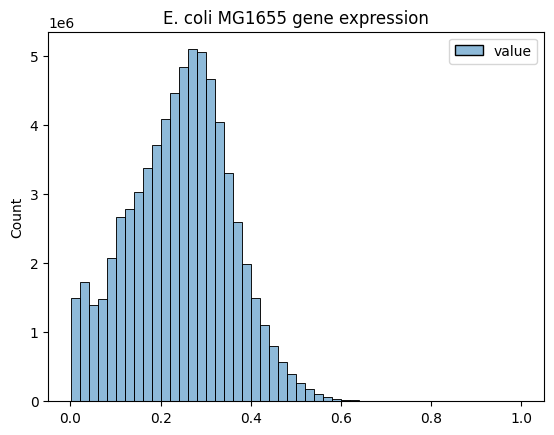

In [11]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)
plt.title("E. coli MG1655 gene expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_initial_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)

### Gene-wise Filtering

In [13]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
11997cc26382b2c286cd502685a104a5_13,16150.0,0.290959,0.049891,0.005090,0.263131,0.284746,0.309190,0.571206
11997cc26382b2c286cd502685a104a5_45,16150.0,0.277920,0.057231,0.002175,0.261675,0.284082,0.305577,0.597320
11997cc26382b2c286cd502685a104a5_102,16150.0,0.213072,0.107602,0.000692,0.119966,0.243526,0.290658,0.742326
11997cc26382b2c286cd502685a104a5_110,16150.0,0.312207,0.066389,0.032919,0.295633,0.324393,0.347428,0.754336
11997cc26382b2c286cd502685a104a5_72,16150.0,0.364656,0.082157,0.022983,0.299426,0.356862,0.427053,0.715735


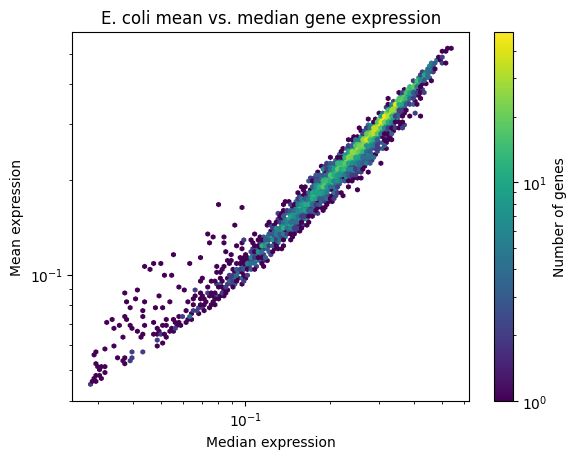

In [14]:
# Preliminary hexagonal binning log-scaled plot of median versus mean
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.colorbar(label = 'Number of genes')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("E. coli mean vs. median gene expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_mean_median_gene.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [17]:
# Empirically determined constants to draw a separation line
c = 0.9
median_cutoff = 0.12

x = np.linspace(median_cutoff, 0.6, 200)
y = c*x

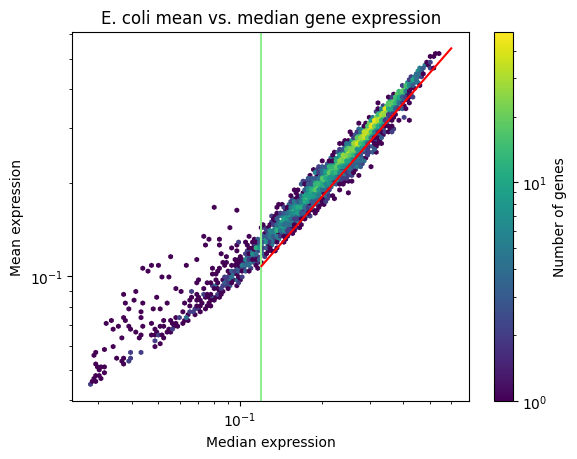

In [18]:
# Hexagonal binning log-scaled plot of median versus mean - included thresholds
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.colorbar(label = 'Number of genes')

plt.axvline(median_cutoff, color = 'lightgreen')
plt.plot(x, y, color = 'red')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("E. coli mean vs. median gene expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_mean_median_gene_thresholds.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [19]:
# Set thresholds to remove genes
threshold1 = median_cutoff
threshold2 = c*gene_stats['50%']

# Genes to remove
genes_to_rm = gene_stats[(gene_stats['50%'] < threshold1) | (gene_stats['mean'] < threshold2)]
genes_to_rm.shape

(664, 8)

In [20]:
# Remove the genes
filtered_genes = all_comp.drop(index = genes_to_rm.index)
filtered_genes.shape

(3608, 16150)

In [21]:
# Get filtered gene stats
filtered_stats = filtered_genes.T.describe().T

Text(0.5, 1.0, 'Mean vs. Median expression')

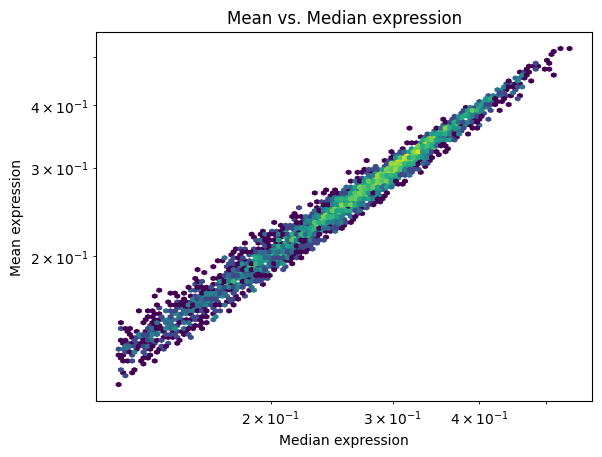

In [22]:
# Plot of gene expression median versus mean after filtering
plt.hexbin(
  x = filtered_stats['50%'],
  y = filtered_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

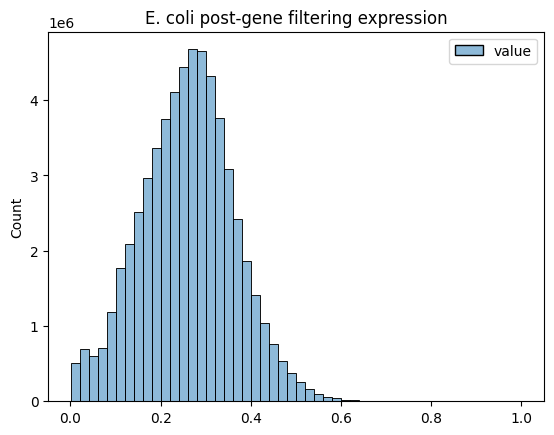

In [24]:
# Histogram of gene expression - getting normal but needs work
sns.histplot(pd.melt(filtered_genes), bins=50)
plt.title("E. coli post-gene filtering expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_genefilt_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)

### Experiment-wise Filtering

In [25]:
# Get experiment statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
ERX358242.salmon,3608.0,0.259334,0.080874,0.037627,0.207913,0.258373,0.309569,0.538706
ERX358243.salmon,3608.0,0.260587,0.085040,0.026616,0.205225,0.260042,0.315398,0.536585
ERX358244.salmon,3608.0,0.259824,0.082692,0.025180,0.207999,0.258959,0.313029,0.527667
ERX358245.salmon,3608.0,0.260435,0.085708,0.039842,0.204903,0.261084,0.316369,0.559430
ERX358246.salmon,3608.0,0.258781,0.089028,0.027814,0.201201,0.258916,0.316990,0.549574


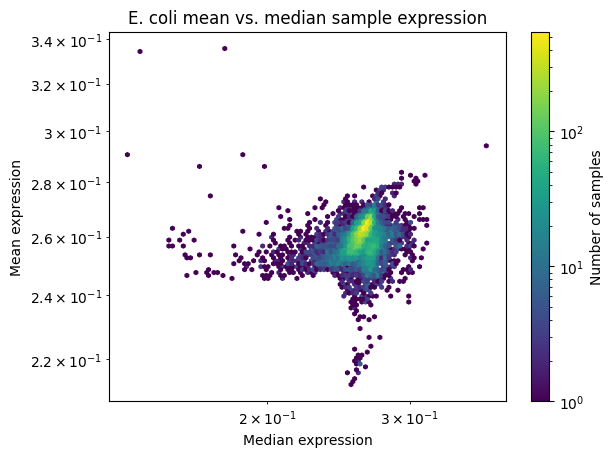

In [26]:
# Prelimiary plot of mean by median expression - weird shape
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.colorbar(label = 'Number of samples')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("E. coli mean vs. median sample expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_mean_median_samp.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [27]:
# Empirically derived constants to filter out samples
c1, c2 = 0.98, 1.02

# Cutoff lines to filter samples
x = np.linspace(0.21, 0.31, 200)
y1 = c1 * x
y2 = c2 * x

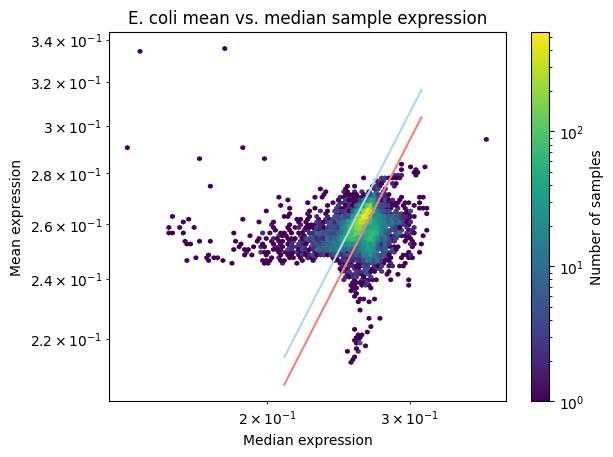

In [28]:
# Plot with threshold lines for filtering out samples
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.colorbar(label = 'Number of samples')

plt.plot(x, y1, color = 'lightcoral')
plt.plot(x, y2, color = 'lightblue')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("E. coli mean vs. median sample expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_mean_median_samp_thresholds.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [29]:
# Thresholds to filter out samples
threshold1 = c1 * exp_stats['50%'] # blue
threshold2 = c2 * exp_stats['50%'] # red

# Samples to remove
exps_to_rm = exp_stats[
  (exp_stats['mean'] < threshold1) |
  (exp_stats['mean'] > threshold2)
]
exps_to_rm.shape

(5909, 8)

In [49]:
# Get final filtered data set
filtered_df = filtered_genes.drop(columns = exps_to_rm.index)
filtered_df.shape

(3608, 10241)

In [31]:
# Get statistics on final data
final_stats = filtered_df.describe().T

Text(0.5, 1.0, 'Mean vs. Median expression')

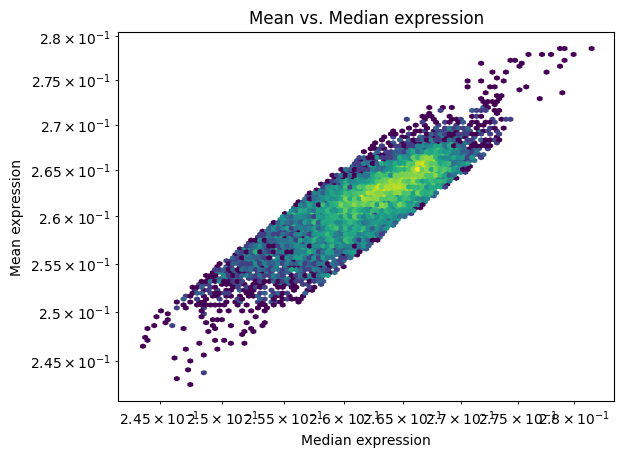

In [32]:
# Plot of filtered samples gene mean versus median
plt.hexbin(
  x = final_stats['50%'],
  y = final_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

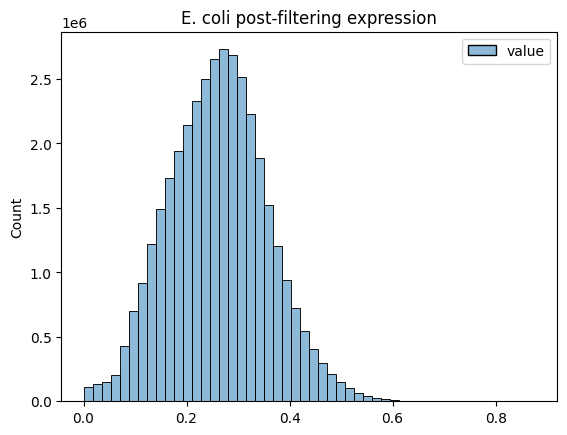

In [35]:
# Histogram of final filtered data - close to normal
sns.histplot(pd.melt(filtered_df), bins = 50)
plt.title("E. coli post-filtering expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_allfilt_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)

### Final Filtered Data

In [36]:
# Get size of filtered genes and samples
filtered_df.shape

(3608, 10241)

## 4. Data post-processing and saving

We pull the raw counts for these filtered data and then normalize again through:
- Ratio of Medians
- Log-transform
- 0-1 scaling

Then, we save the data to a CSV. Now, we annotate the metadata with the reasons on why each sample was either included or excluded.

### Save filtered data to CSV

In [50]:
# Remove ill-formatted columns
bad_cols = [
  'df2...c.3.ncol.df2....37', 'df2...c.3.ncol.df2....38',
  'df2...c.3.ncol.df2....39', 'df2...c.3.ncol.df2....40',
  'df2...c.3.ncol.df2....41', 'df2...c.3.ncol.df2....42',
  'df2...c.3.ncol.df2....50', 'df2...c.3.ncol.df2....52'
]
filtered_df = filtered_df.drop(columns = bad_cols)
filtered_df.shape

(3608, 10233)

In [51]:
raw_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/num_reads_ecoli_pan_genome_part2_comp_ref_k15v3.csv',
  index_col = 0
)
raw_df.shape

(59521, 20241)

In [52]:
raw_df.index = raw_df['X']
raw_filt = raw_df.loc[filtered_df.index, filtered_df.columns]
raw_filt.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,89.000,210.000,184.000,97.000,138.000,147.000,372.990,115.000,29.022,57.192,...,1293.000,2456.0,1020.0,2966.00,2871.0,832.0,1343.000,1036.00,948.000,1176.000
11997cc26382b2c286cd502685a104a5_45,190.000,247.000,353.000,111.000,263.000,108.000,326.000,104.000,17.979,23.869,...,1592.000,2505.0,1812.0,506.25,647.0,501.0,761.877,563.00,611.659,599.889
11997cc26382b2c286cd502685a104a5_110,512.188,774.683,494.736,375.694,411.855,148.855,1310.018,278.331,26.225,25.298,...,4473.000,5772.0,3436.0,2976.00,4803.0,2792.0,2721.000,2274.00,2376.000,2393.000
11997cc26382b2c286cd502685a104a5_72,364.959,1070.884,348.464,655.238,418.039,217.520,1457.939,169.932,234.191,251.888,...,73509.995,105679.0,54749.0,1928.00,1996.0,8069.0,10965.000,8550.86,8671.000,105943.000
11997cc26382b2c286cd502685a104a5_273,100.000,168.000,70.185,0.000,0.000,28.000,106.000,72.000,10.000,7.000,...,190.000,262.0,157.0,183.00,253.0,120.0,116.000,100.00,73.000,83.000


In [53]:
# Ratio of Medians Scaling
norm_counts, size_factors = deseq2_norm(raw_filt.T)
norm_counts = norm_counts.T
norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,166.912207,223.459767,200.081590,169.117601,139.859674,232.681865,199.242143,279.369122,492.746886,784.294957,...,305.307864,418.189651,281.542283,1129.955156,853.935072,302.041234,364.800102,353.169134,333.069866,436.604125
11997cc26382b2c286cd502685a104a5_45,356.329432,262.831249,383.852181,193.526326,266.544162,170.949942,174.141233,252.646859,305.254505,327.324387,...,375.908832,426.533012,500.151586,192.865744,192.440262,181.878195,206.949223,191.924925,214.899980,222.715997
11997cc26382b2c286cd502685a104a5_110,960.566626,824.335630,537.975899,655.015132,417.405118,235.618088,699.779602,676.148585,445.258324,346.920790,...,1056.181033,982.813790,948.411064,1133.764850,1428.578945,1013.580679,739.107280,775.199431,834.782701,888.429993
11997cc26382b2c286cd502685a104a5_72,684.450700,1139.521374,378.919734,1142.394622,423.672453,344.305845,778.795385,412.815250,3976.186545,3454.232902,...,17357.447447,17994.244363,15111.920071,734.508948,593.679695,2929.291727,2978.431210,2914.961218,3046.464983,39332.611257
11997cc26382b2c286cd502685a104a5_273,187.541806,178.767813,76.319165,0.000000,0.000000,44.320355,56.622610,174.909364,169.783918,95.993578,...,44.863491,44.611437,43.335430,69.717395,75.250983,43.563640,31.509167,34.089685,25.647785,30.814747


In [54]:
# Log2 scaling
log_norm_counts = np.log2(norm_counts + 1)
log_norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,7.391563,7.810313,7.651637,7.410389,7.138115,7.868402,7.645602,8.131184,8.947628,9.617091,...,8.258839,8.711459,8.142323,10.143326,9.739671,8.243370,8.514912,8.468295,8.384006,8.773483
11997cc26382b2c286cd502685a104a5_45,8.481111,8.043472,8.588161,7.603822,8.063633,7.425845,7.452375,7.986677,8.258587,8.358978,...,8.558072,8.739892,8.969103,7.598914,7.595744,7.514739,7.700087,7.591896,7.754219,7.805525
11997cc26382b2c286cd502685a104a5_110,9.909243,9.688837,9.074077,9.357585,8.708757,7.886417,9.452817,9.403329,8.801735,8.442615,...,10.046007,9.942241,9.890889,10.148178,10.481375,9.986668,9.531591,9.600284,9.706984,9.796737
11997cc26382b2c286cd502685a104a5_72,9.420909,10.155478,8.569551,10.159108,8.730207,8.431731,9.606952,8.692843,11.957533,11.754567,...,14.083350,14.135328,13.883495,9.522599,9.215969,11.516829,11.540821,11.509756,11.573394,15.263475
11997cc26382b2c286cd502685a104a5_273,7.558741,7.489991,6.272754,0.000000,0.000000,5.502087,5.848563,7.458688,7.416028,6.599817,...,5.519274,5.511324,5.470388,6.143993,6.252684,5.477795,5.022775,5.132975,4.735944,4.991624


In [55]:
# 0-1 scaling
log_01_norm_counts = (log_norm_counts - log_norm_counts.min()) / (log_norm_counts.max() - log_norm_counts.min())
log_01_norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,0.461664,0.494183,0.487808,0.452583,0.445591,0.461809,0.472946,0.487525,0.519527,0.539246,...,0.499022,0.528088,0.489925,0.600860,0.579803,0.501336,0.517328,0.516401,0.511607,0.523643
11997cc26382b2c286cd502685a104a5_45,0.529715,0.508935,0.547514,0.464397,0.503366,0.435835,0.460993,0.478861,0.479520,0.468701,...,0.517102,0.529812,0.539672,0.450136,0.452175,0.457023,0.467823,0.462958,0.473176,0.465870
11997cc26382b2c286cd502685a104a5_110,0.618914,0.613043,0.578492,0.571506,0.543637,0.462867,0.584738,0.563800,0.511056,0.473391,...,0.607007,0.602698,0.595136,0.601147,0.623957,0.607359,0.579096,0.585431,0.592337,0.584715
11997cc26382b2c286cd502685a104a5_72,0.588414,0.642569,0.546327,0.620458,0.544976,0.494872,0.594272,0.521201,0.694292,0.659097,...,0.850955,0.856883,0.835372,0.564090,0.548627,0.700418,0.701168,0.701871,0.706229,0.910996
11997cc26382b2c286cd502685a104a5_273,0.472106,0.473915,0.399902,0.000000,0.000000,0.322927,0.361784,0.447204,0.430598,0.370062,...,0.333490,0.334096,0.329154,0.363951,0.372223,0.333143,0.305161,0.313012,0.288996,0.297924


In [56]:
# Save to a CSV file
log_01_norm_counts.to_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01_medmean_normal_muk.csv',
  index = True
)

In [57]:
# Verify that I can load the CSV back in here
filtered_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01_medmean_normal_muk.csv',
  index_col = 0
)
filtered_df.shape

(3608, 10233)

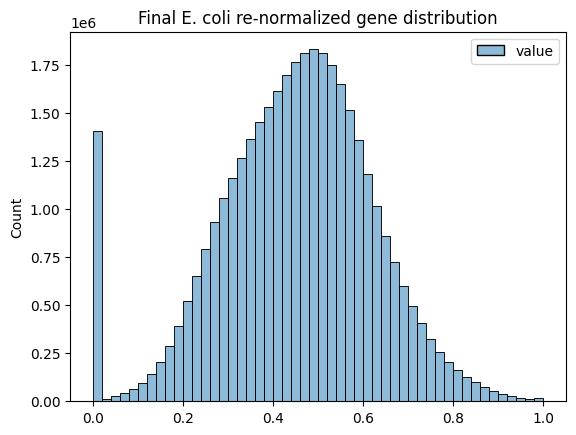

In [58]:
# Final data distribution
sns.histplot(pd.melt(filtered_df), bins = 50)
plt.title("Final E. coli re-normalized gene distribution")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/ec_mg1655_final_renorm_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)

### Annotate and save metadata

In [ ]:
# Load SRA metadata
m_df = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/SraRunTable_Ec_07_25_25_working_v4.csv')
m_df.shape

/tmp/ipykernel_9209/252325048.py:2: DtypeWarning: Columns (0: temperature, 1: Group, 2: Source, 3: Experiment.1, 4: timepoint, 5: Day, 6: induction_time, 7: growth_phase, 8: samp_size, 9: induction_concentration, 10: Biological_Replicate, 11: plasmid, 12: culture_type, 13: molecule_subtype, 14: culture_collection, 15: Serovar, 16: altitude, 17: passage_history, 18: mating_type, 19: Depth, 20: host_tissue_sampled, 21: identified_by, 22: Specimen_voucher, 23: gene_expressed, 24: time_point, 25: moa, 26: medium, 27: Espinoza_et_al, 28: id_jira, 29: ORourke_et_al, 30: cpd_local, 31: cpd_universal, 32: ctrl_local, 33: ctrl_universal, 34: id_espinoza.et.al, 35: id_orourke.et.al, 36: id_sequencing.number, 37: moa_color, 38: og_moa, 39: sample.category, 40: carbon_source, 41: neu_sub.moa, 42: gene_target_description, 43: neu_sub.moa_description, 44: project_name, 45: Investigation_type, 46: Phase, 47: Sequencing_method, 48: environment_.biome., 49: environment_.feature., 50: environment_.mater

(22109, 163)

In [ ]:
# Assign all samples and samples that passed filtering to lists
all_samps = all_comp.columns.tolist()
passed_filt = [col[:-7] for col in filtered_df.columns]

In [ ]:
# Add column on whether each sample passed my filtering
m_df['MT..Passed_filtering'] = m_df['Experiment'].isin(passed_filt)
m_df['MT..Passed_filtering'].value_counts()

MT..Passed_filtering
True     11219
False    10890
Name: count, dtype: int64

In [ ]:
def assign_region(sample):
  """
  Return the reason why this sample was included/excluded after
  my filtering.
  """
  exp = sample["Experiment"]
  key = f"{exp}.salmon"

  if key not in all_samps:
    return "Unused"

  if exp in passed_filt:
    return "Mean ≈ Median"

  if exp_stats.at[key, "mean"] > c1 * exp_stats.at[key, "50%"]:
    return "Right-skewed"

  if exp_stats.at[key, "mean"] < c2 * exp_stats.at[key, "50%"]:
    return "Left-skewed"

# Apply the function across all rows
m_df["MT..Notes"] = m_df.apply(assign_region, axis=1)

In [ ]:
m_df['MT..Notes'].value_counts()

MT..Notes
Mean ≈ Median    11219
Unused            4689
Left-skewed       4028
Right-skewed      2173
Name: count, dtype: int64

In [ ]:
def categorize_notes(note):
  """
  Return the appropriate category for the JK notes
  column.
  """
  if pd.isna(note) or str(note).strip() == "":
    return "Empty"

  text = str(note).lower()

  if re.search(r"\bmaybe\b", text):
    return "Maybe"
  elif re.search(r"\byes\b", text):
    return "Yes"
  elif re.search(r"\bno\b", text):
    return "No"
  else:
    return "Empty"

m_df["JK_category"] = m_df["JK..Notes."].apply(categorize_notes)

In [ ]:
m_df['JK_category'].value_counts()

JK_category
Empty    21959
Yes         91
No          42
Maybe       17
Name: count, dtype: int64

In [ ]:
m_df.tail()

,Unnamed: 0,X,Run,Assay.Type,BioProject,BioSample,Center.Name,Consent,DATASTORE.filetype,DATASTORE.provider,...,hk_test,zc_test,passed_filtering,X.1,JK..Notes.,Sequencing.Notes..JK.,Metagenomic.libraries..JK.,MT..Passed_filtering,MT..Notes,JK_category
22104,22105,4849,ERR11572062,WGS,PRJEB63260,SAMEA113611612,Emma Bartram,public,"sra,fastq,run.zq","ncbi,gs,s3",...,pass,pass,TRUE,NaN,NaN,NaN,NaN,False,Right-skewed,Empty
22105,22106,4850,ERR11572063,WGS,PRJEB63260,SAMEA113611613,Emma Bartram,public,"sra,fastq,run.zq","ncbi,gs,s3",...,pass,pass,TRUE,NaN,NaN,NaN,NaN,False,Right-skewed,Empty
22106,22107,4851,ERR11572064,WGS,PRJEB63260,SAMEA113611614,Emma Bartram,public,"sra,run.zq,fastq","ncbi,gs,s3",...,pass,pass,TRUE,NaN,NaN,NaN,NaN,False,Right-skewed,Empty
22107,22108,9517,SRR6801477,WGS,PRJNA434567,SAMN08631455,ARBOR BIOTECHNOLOGIES,public,"fastq,run.zq,sra","gs,ncbi,s3",...,pass,pass,TRUE,NaN,NaN,NaN,NaN,False,Left-skewed,Empty
22108,22109,9518,SRR6801478,WGS,PRJNA434567,SAMN08631464,ARBOR BIOTECHNOLOGIES,public,"fastq,run.zq,sra","gs,ncbi,s3",...,pass,pass,TRUE,NaN,NaN,NaN,NaN,True,Mean ≈ Median,Empty


In [ ]:
# Save annotated metadata to CSV
m_df.to_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/mt_filtering_annotated_sra.csv',
  index = True
)

In [ ]:
# Verify I can load back in the annotated metadata
m_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/mt_filtering_annotated_sra.csv'
)
m_df.head()

/tmp/ipykernel_9209/2533839282.py:2: DtypeWarning: Columns (0: temperature, 1: Group, 2: Source, 3: Experiment.1, 4: timepoint, 5: Day, 6: induction_time, 7: growth_phase, 8: samp_size, 9: induction_concentration, 10: Biological_Replicate, 11: plasmid, 12: culture_type, 13: molecule_subtype, 14: culture_collection, 15: Serovar, 16: altitude, 17: passage_history, 18: mating_type, 19: Depth, 20: host_tissue_sampled, 21: identified_by, 22: Specimen_voucher, 23: gene_expressed, 24: time_point, 25: moa, 26: medium, 27: Espinoza_et_al, 28: id_jira, 29: ORourke_et_al, 30: cpd_local, 31: cpd_universal, 32: ctrl_local, 33: ctrl_universal, 34: id_espinoza.et.al, 35: id_orourke.et.al, 36: id_sequencing.number, 37: moa_color, 38: og_moa, 39: sample.category, 40: carbon_source, 41: neu_sub.moa, 42: gene_target_description, 43: neu_sub.moa_description, 44: project_name, 45: Investigation_type, 46: Phase, 47: Sequencing_method, 48: environment_.biome., 49: environment_.feature., 50: environment_.mate

,Unnamed: 0.1,Unnamed: 0,X,Run,Assay.Type,BioProject,BioSample,Center.Name,Consent,DATASTORE.filetype,...,hk_test,zc_test,passed_filtering,X.1,JK..Notes.,Sequencing.Notes..JK.,Metagenomic.libraries..JK.,MT..Passed_filtering,MT..Notes,JK_category
0,0,1,1894,SRR18365054,AMPLICON,PRJNA807096,SAMN26794078,ETH ZURICH,public,"fastq,sra,run.zq",...,fail low,pass,FALSE,NaN,No - host is human,"Amplicon - type of DNA sequencing, uses PCR to...",NaN,False,Unused,No
1,1,2,4702,SRR24135199,AMPLICON,PRJNA954059,SAMN34145679,RICE UNIVERSITY,public,"run.zq,sra,fastq",...,fail low,pass,FALSE,NaN,No - host is human,"""Amplicon sequencing is a targetted DNA sequen...",NaN,False,Unused,No
2,2,3,5976,SRR7362921,AMPLICON,PRJNA476703,SAMN09453320,ICBFM SB RAS,public,"fastq,run.zq,sra",...,fail low,pass,FALSE,NaN,No- not RNA seq,specific genomic DNA regions. Uses PCR to ampl...,NaN,False,Unused,No
3,3,4,13666,SRR28810939,AMPLICON,PRJNA1104763,SAMN41086125,XINJIANG AGRICULTURAL UNIVERSITY,public,"run.zq,fastq,sra",...,fail low,pass,FALSE,NaN,Maybe? unknown/missing host,"with custom primers, followed by high-throughp...",Homo Sapian,False,Unused,Maybe
4,4,5,18102,ERR5699662,AMPLICON,PRJEB44243,SAMEA8552548,UNIVERSITY OF FLORENCE,public,"run.zq,sra,fastq",...,fail low,pass,FALSE,NaN,No - host is human,"genetic variation, microbe composition, or mut...",NaN,False,Unused,No


### Summary tables against Jessica's notes

In [ ]:
srx_summary = (
  m_df.drop_duplicates(subset=["Experiment", "MT..Passed_filtering", "JK_category"])
    .groupby(["MT..Passed_filtering", "JK_category"])["Experiment"]
    .nunique()
    .unstack(fill_value=0)
)

# Optional totals
srx_summary["Total"] = srx_summary.sum(axis=1)
srx_summary.loc["Total"] = srx_summary.sum(axis=0)

print(srx_summary)

JK_category           Empty  Maybe  No  Yes  Total
MT..Passed_filtering                              
False                  9909     17  42   91  10059
True                  10233      0   0    0  10233
Total                 20142     17  42   91  20292


In [ ]:
srp_summary = (
  m_df.drop_duplicates(subset=["SRA.Study", "MT..Passed_filtering", "JK_category"])
    .groupby(["MT..Passed_filtering", "JK_category"])["SRA.Study"]
    .nunique()
    .unstack(fill_value=0)
)

# Optional totals
srp_summary["Total"] = srp_summary.sum(axis=1)
srp_summary.loc["Total"] = srp_summary.sum(axis=0)

print(srp_summary)

JK_category           Empty  Maybe  No  Yes  Total
MT..Passed_filtering                              
False                  1009      2   4    1   1016
True                    855      0   0    0    855
Total                  1864      2   4    1   1871
